# Analysis of Weighted VC Repairer Sweeps (May 15, 2026)

This notebook analyzes the alpha and epsilon sweeps for the updated `WeightedVCRepairer` which now uses a squared error term in its weight function.

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob

%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
def load_results(base_path):
    results = []
    # Use glob to find all json files recursively, handles path separators better
    json_files = glob.glob(os.path.join(base_path, "**", "*.json"), recursive=True)
    
    for file_path in json_files:
        try:
            with open(file_path, 'r') as f_in:
                data = json.load(f_in)
                
                # Flatten some nested structures
                entry = {
                    'experiment_name': data.get('experiment_name'),
                    'dataset': data.get('dataset_name'),
                    'deletion_ratio': data.get('deletion_ratio', {}).get('ratio'),
                    'repair_runtime': data.get('runtimes', {}).get('repairing'),
                    'repaired_marginal_error': data.get('marginals_error', {}).get('repaired_avg'),
                    'repaired_tvd_2way': data.get('tvd_2way', {}).get('repaired_avg'),
                }
                
                # Total runtime
                if data.get('runtimes'):
                    entry['total_runtime'] = sum(data['runtimes'].values())
                
                # Mean ML accuracy (repaired)
                ml_repaired = data.get('ml_accuracy', {}).get('repaired', {})
                if ml_repaired:
                    entry['ml_accuracy_mean'] = np.mean(list(ml_repaired.values()))
                
                # Extract alpha/eps from name
                name = entry['experiment_name']
                if name:
                    parts = name.split('_')
                    if 'alpha_v4' in name and len(parts) >= 7:
                        entry['sweep_type'] = 'alpha'
                        entry['model'] = parts[5]
                        entry['alpha'] = float(parts[6][1:])
                    elif 'eps_v4' in name and len(parts) >= 8:
                        entry['sweep_type'] = 'epsilon'
                        entry['model'] = parts[5]
                        entry['epsilon'] = float(parts[6][3:])
                        entry['alpha'] = float(parts[7][1:])
                
                results.append(entry)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            
    return pd.DataFrame(results)

# Search in parent directory as well just in case of notebook location issues
base_path = os.path.join("..", "results_may15", "results")
if not os.path.exists(base_path):
    base_path = os.path.join("results_may15", "results")

print(f"Searching for results in: {os.path.abspath(base_path)}")
df = load_results(base_path)

if df.empty:
    print("Warning: No results loaded. Found 0 JSON files or failed to parse them.")
else:
    print(f"Loaded {len(df)} results.")
    display(df.head())

Searching for results in: c:\Users\itayc\OneDrive\Desktop\Master\final\results_may15\results
Loaded 307 results.


,experiment_name,dataset,deletion_ratio,repair_runtime,repaired_marginal_error,repaired_tvd_2way,total_runtime,ml_accuracy_mean,sweep_type,model,alpha,epsilon
0,weighted_updated_alpha_v4_adult_aim_a0.0,adult,0.99802,65804.794853,0.134505,0.269344,65811.455548,0.790078,alpha,aim,0.00,NaN
1,weighted_updated_alpha_v4_adult_aim_a0.05,adult,0.86156,24977.453935,0.097580,0.151747,24984.131168,0.835265,alpha,aim,0.05,NaN
2,weighted_updated_alpha_v4_adult_aim_a0.1,adult,0.86156,22281.250520,0.066527,0.145805,22285.188682,0.834923,alpha,aim,0.10,NaN
3,weighted_updated_alpha_v4_adult_aim_a0.15,adult,0.86156,20877.474053,0.065332,0.145451,20881.306308,0.834289,alpha,aim,0.15,NaN
4,weighted_updated_alpha_v4_adult_aim_a0.25,adult,0.84176,24884.011389,0.217846,0.155019,24890.674342,0.834855,alpha,aim,0.25,NaN


## Alpha Sweep Analysis

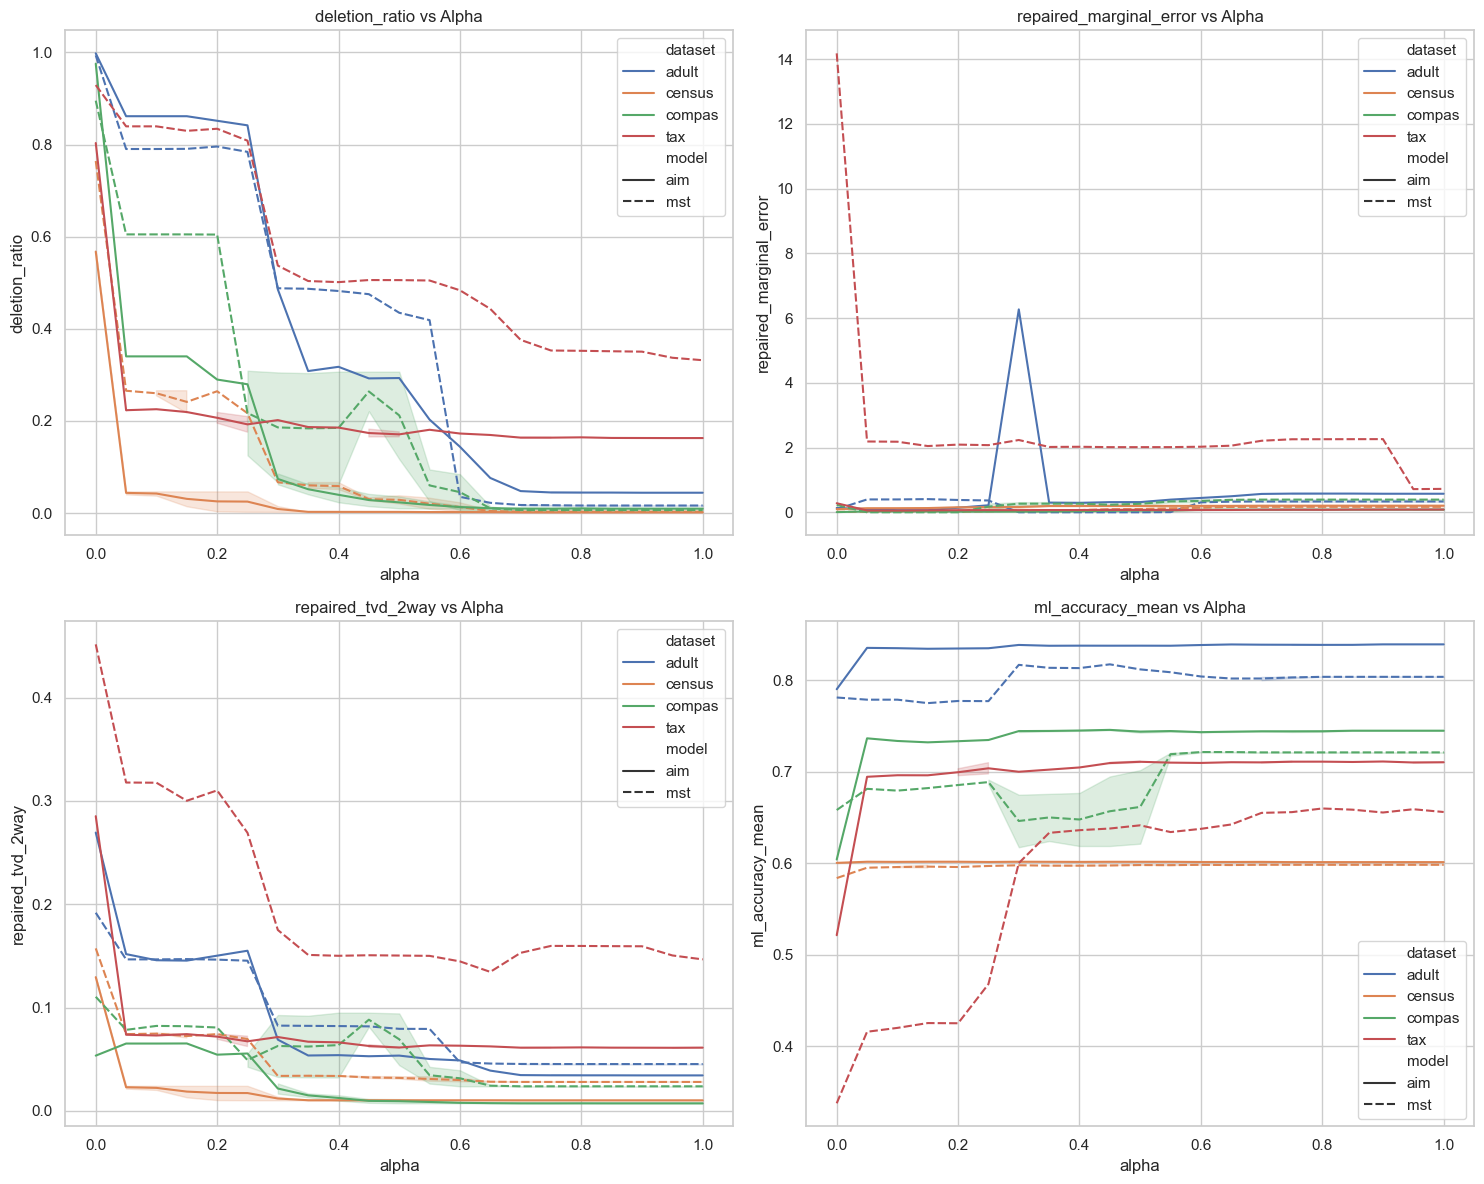

In [4]:
if not df.empty and 'alpha' in df.columns:
    alpha_df = df[df['sweep_type'] == 'alpha'].sort_values('alpha')
    
    if not alpha_df.empty:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        metrics = ['deletion_ratio', 'repaired_marginal_error', 'repaired_tvd_2way', 'ml_accuracy_mean']
        
        for i, metric in enumerate(metrics):
            if metric in alpha_df.columns:
                ax = axes[i//2, i%2]
                sns.lineplot(data=alpha_df, x='alpha', y=metric, hue='dataset', style='model', ax=ax)
                ax.set_title(f'{metric} vs Alpha')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No alpha sweep results found.")

## Epsilon Sweep Analysis

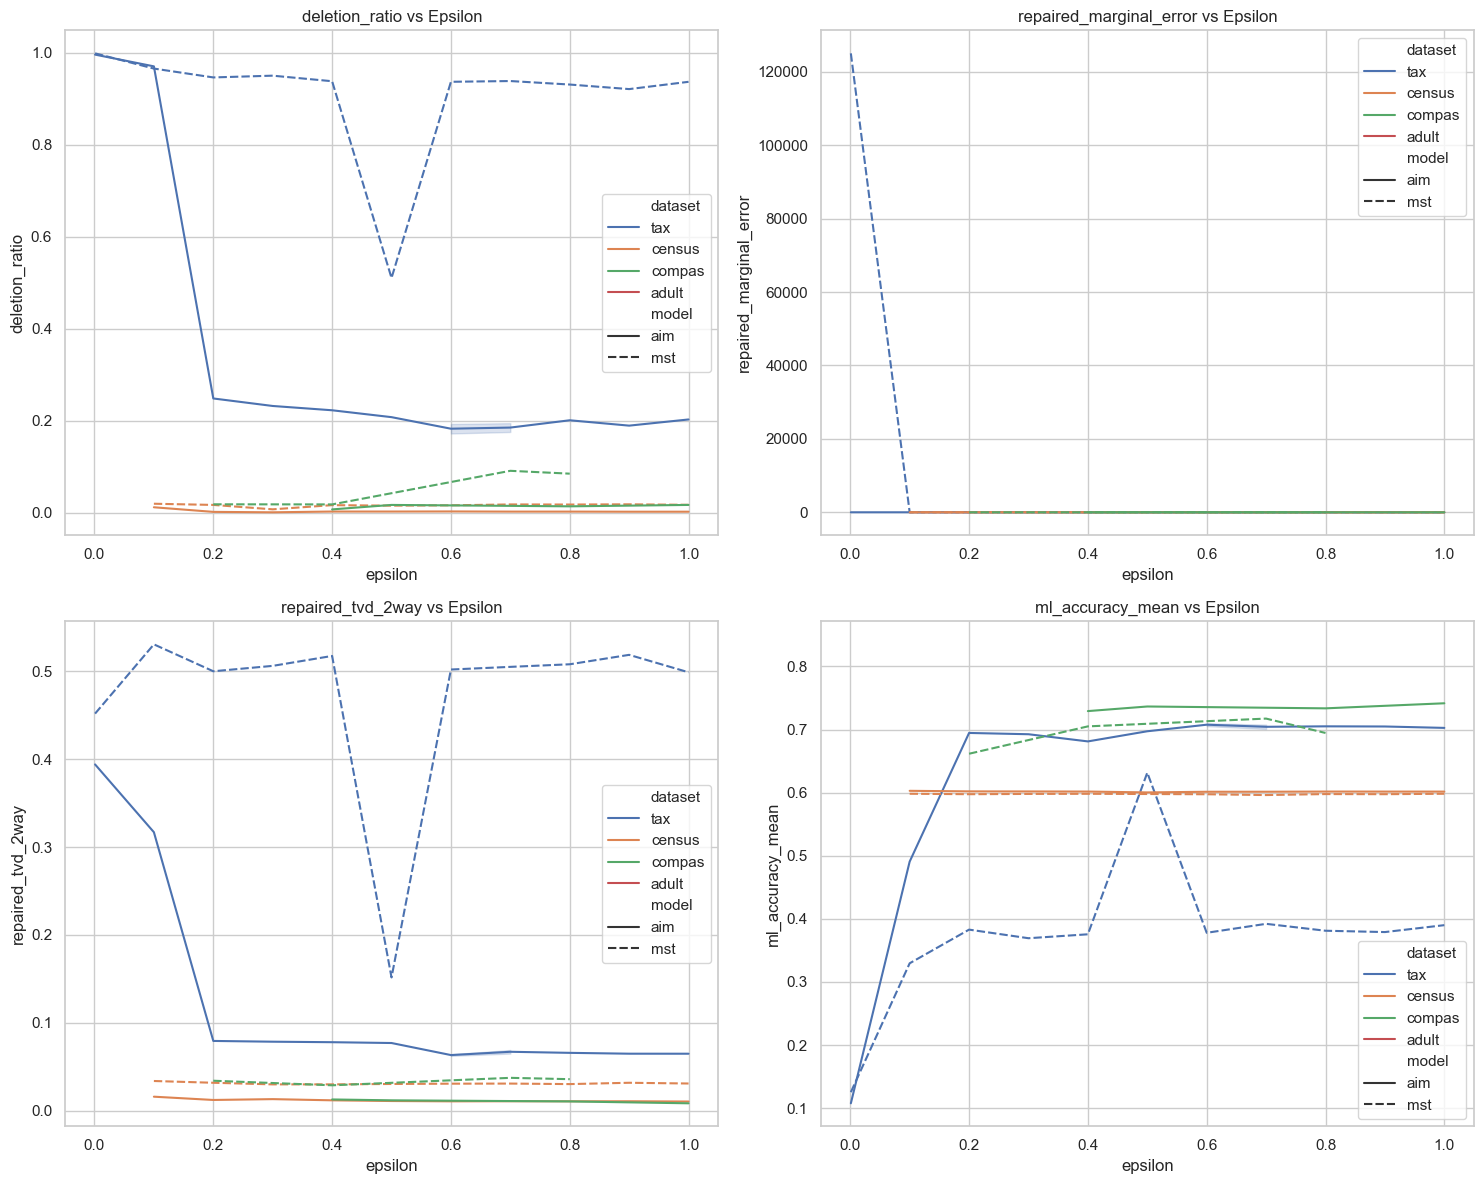

In [5]:
if not df.empty and 'epsilon' in df.columns:
    eps_df = df[df['sweep_type'] == 'epsilon'].sort_values('epsilon')
    
    if not eps_df.empty:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        for i, metric in enumerate(metrics):
            if metric in eps_df.columns:
                ax = axes[i//2, i%2]
                sns.lineplot(data=eps_df, x='epsilon', y=metric, hue='dataset', style='model', ax=ax)
                #ax.set_xscale('log')
                ax.set_title(f'{metric} vs Epsilon')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No epsilon sweep results found.")